In [11]:
from transformers import GPT2LMHeadModel

/home/jimmyjia/JimmyJia_Proj/study_notebook/jimmy-gpt2/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [12]:
model_hf = GPT2LMHeadModel.from_pretrained("gpt2") #124
# .state_dict(): a dictionary mapping each parameter name to its value(Tensor).
sd_hf = model_hf.state_dict()

# .items() gives dict's contents as (key, value)
for k, v in sd_hf.items():
    print(k,v.shape)

Loading weights: 100%|██████████| 148/148 [00:00<00:00, 23271.99it/s]

transformer.wte.weight torch.Size([50257, 768])
transformer.wpe.weight torch.Size([1024, 768])
transformer.h.0.ln_1.weight torch.Size([768])
transformer.h.0.ln_1.bias torch.Size([768])
transformer.h.0.attn.c_attn.weight torch.Size([768, 2304])
transformer.h.0.attn.c_attn.bias torch.Size([2304])
transformer.h.0.attn.c_proj.weight torch.Size([768, 768])
transformer.h.0.attn.c_proj.bias torch.Size([768])
transformer.h.0.ln_2.weight torch.Size([768])
transformer.h.0.ln_2.bias torch.Size([768])
transformer.h.0.mlp.c_fc.weight torch.Size([768, 3072])
transformer.h.0.mlp.c_fc.bias torch.Size([3072])
transformer.h.0.mlp.c_proj.weight torch.Size([3072, 768])
transformer.h.0.mlp.c_proj.bias torch.Size([768])
transformer.h.1.ln_1.weight torch.Size([768])
transformer.h.1.ln_1.bias torch.Size([768])
transformer.h.1.attn.c_attn.weight torch.Size([768, 2304])
transformer.h.1.attn.c_attn.bias torch.Size([2304])
transformer.h.1.attn.c_proj.weight torch.Size([768, 768])
transformer.h.1.attn.c_proj.bias 

In [16]:
sd_hf["transformer.wpe.weight"].view(-1)[:20]

tensor([-0.0188, -0.1974,  0.0040,  0.0113,  0.0638, -0.1050,  0.0369, -0.1680,
        -0.0491, -0.0565, -0.0025,  0.0135, -0.0042,  0.0151,  0.0166, -0.1381,
        -0.0063, -0.0461,  0.0267, -0.2042])

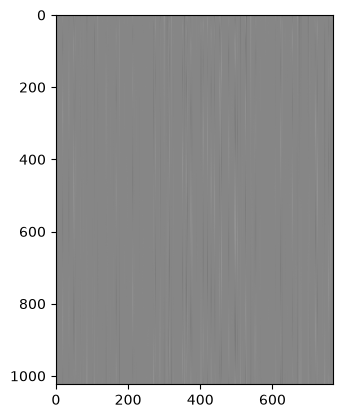

In [22]:
import matplotlib.pyplot as plt
%matplotlib inline
plt.imshow(sd_hf["transformer.wpe.weight"], cmap="grey")

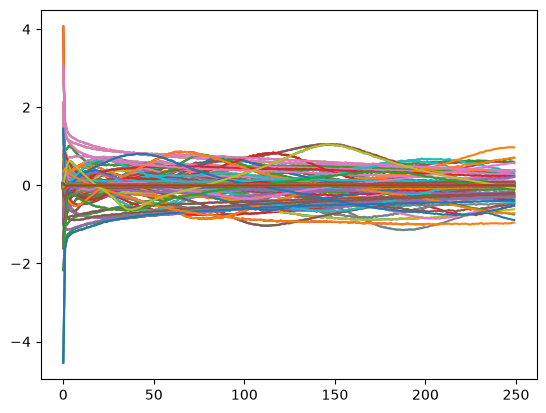

In [25]:
plt.plot(sd_hf["transformer.wpe.weight"][:150])
plt.plot(sd_hf["transformer.wpe.weight"][:200])
plt.plot(sd_hf["transformer.wpe.weight"][:250])

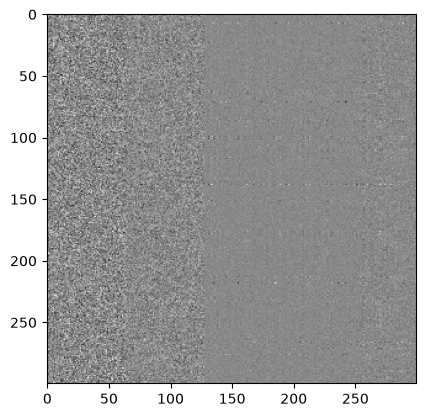

In [32]:
plt.imshow(sd_hf["transformer.h.1.attn.c_attn.weight"][:300,:300],cmap="gray")

In [3]:
from transformers import pipeline,set_seed
generator = pipeline("text-generation", model="gpt2")
set_seed(42)
generator("President ",max_length=30,num_return_sequences=5)

Loading weights: 100%|██████████| 148/148 [00:00<00:00, 20990.67it/s]
[transformers] Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.
[transformers] Both `max_new_tokens` (=256) and `max_length`(=30) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


[{'generated_text': 'President ?" He asked. "They said, \'We have no choice, we have to leave.\'"\n\n"What do you mean?" I asked.\n\n"They said, \'We\'re not going to leave you.\'"\n\n"We\'re not leaving you," he said. "We\'re not going to leave you."\n\nWe walked off.\n\nI was in the same mood as the rest of the group. The room was almost empty except for the two men sitting on chairs. I took a seat, and asked, "What if you\'re coming back? Would you not like that?"\n\n"Well, if I could, I would. If I could, I would. But if I could, I would not." I had no idea how he could do that, and I didn\'t want to do it either, so I moved on.\n\nI was there for about 25 minutes. I didn\'t want to go back to the room that night. I would have to do it myself if I wanted to.\n\nThe next day, I woke up with a broken leg. I had been in the hospital for about four hours, and I hadn\'t been able to walk for about a week. I was worried that I would be'},
 {'generated_text': 'President .")\n\nAfter the w

## Get datasets

In [3]:
# tiny shakespeare datasets
# !wget https://raw.githubusercontent.com/karpathy/char-rnn/master/data/tinyshakespeare/input.txt
with open("../datasets/input.txt") as f:
    text = f.read()
data = text[:10000]
print(data[:1000])


First Citizen:
Before we proceed any further, hear me speak.

All:
Speak, speak.

First Citizen:
You are all resolved rather to die than to famish?

All:
Resolved. resolved.

First Citizen:
First, you know Caius Marcius is chief enemy to the people.

All:
We know't, we know't.

First Citizen:
Let us kill him, and we'll have corn at our own price.
Is't a verdict?

All:
No more talking on't; let it be done: away, away!

Second Citizen:
One word, good citizens.

First Citizen:
We are accounted poor citizens, the patricians good.
What authority surfeits on would relieve us: if they
would yield us but the superfluity, while it were
wholesome, we might guess they relieved us humanely;
but they think we are too dear: the leanness that
afflicts us, the object of our misery, is as an
inventory to particularise their abundance; our
sufferance is a gain to them Let us revenge this with
our pikes, ere we become rakes: for the gods know I
speak this in hunger for bread, not in thirst for revenge.



# Tokenization for datasets

In [5]:
import tiktoken
enc = tiktoken.get_encoding("gpt2")
tokens = enc.encode(data)
print(len(tokens))
print(tokens[:24])

2805
[5962, 22307, 25, 198, 8421, 356, 5120, 597, 2252, 11, 3285, 502, 2740, 13, 198, 198, 3237, 25, 198, 5248, 461, 11, 2740, 13]


### Reshape single token tensor into (batch, Tokens)

In [9]:
import torch
buf = torch.tensor(tokens[:24 + 1]) # Take 25 tokens (indices 0-24)
x = buf[:-1].view(4,6) # Given tokens[0:24] - everything EXCEPT the last
y = buf[1:].view(4,6) # Label: [1:25] - everything INCLUDING the last
# Position:  0    1    2    3    4    5
# x:        [A,   B,   C,   D,   E,   F ]
# y:        [B,   C,   D,   E,   F,   G ]
print(x)
print(y)

tensor([[ 5962, 22307,    25,   198,  8421,   356],
        [ 5120,   597,  2252,    11,  3285,   502],
        [ 2740,    13,   198,   198,  3237,    25],
        [  198,  5248,   461,    11,  2740,    13]])
tensor([[22307,    25,   198,  8421,   356,  5120],
        [  597,  2252,    11,  3285,   502,  2740],
        [   13,   198,   198,  3237,    25,   198],
        [ 5248,   461,    11,  2740,    13,   198]])


## Weight sharing
### The token embedding weight and the language model weight are the same

In [13]:
print(sd_hf["transformer.wte.weight"].shape)
print(sd_hf["lm_head.weight"].shape)

(sd_hf["transformer.wte.weight"] == sd_hf["lm_head.weight"]).all()

print(sd_hf["transformer.wte.weight"].data_ptr() == sd_hf["lm_head.weight"].data_ptr())

torch.Size([50257, 768])
torch.Size([50257, 768])
True


In [37]:
# standard deviation grows inside the residual stream
x = torch.zeros(768)
print(x.std())

n = 100 # e.g. 100 layers
for i in range(n):
    x += torch.randn(768)

print(x.std())

x = torch.zeros(768)
for i in range(n):
    x += n**-0.5 * torch.randn(768)

print(x.std())


tensor(0.)
tensor(9.7650)
tensor(0.9777)
